# 3DVar on Lorenz-63 — analysis + free forecast

Same cost function as OI / BLUE — but minimised by an iterative
optimiser (`optimistix.BFGS`) instead of a closed-form Kalman gain.
In the linear-Gaussian limit the two methods produce the **identical**
answer (Decision D14 invariant). We verify that here and then
free-forecast the analysis to 10 time units to see the chaotic
divergence.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import vardax as vdx

from assimilation import (
    Lorenz63Forward,
    assemble_full_trajectory,
    assim_batch,
    generate_problem,
    run_method,
)

## 1. Shared problem

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = assim_batch(prob)
fwd = Lorenz63Forward(dt=prob.dt)
t_axis = jnp.arange(prob.T_total_plus_1) * prob.dt

## 2. Build 3DVar

In [3]:
H = lx.IdentityLinearOperator(jax.ShapeDtypeStruct(prob.prior_mean.shape, jnp.float32))
three = vdx.ThreeDVar(
    obs_op=vdx.LinearObs(H_mat=H),
    prior_mean=prob.prior_mean,
    prior_cov_op=prob.B_op,
    obs_cov_op=prob.R_op,
    max_steps=1000,
)


def three_run():
    return assemble_full_trajectory(three(batch)[0], prob, fwd)


result = run_method("3dvar", three_run, prob)
print(f"3DVar rmse_assim    = {result.rmse_assim:.3f}")
print(f"3DVar rmse_forecast = {result.rmse_forecast:.3f}")
print(f"3DVar rmse_total    = {result.rmse_total:.3f}")
print(f"3DVar runtime       = {result.runtime_ms:.1f} ms")

3DVar rmse_assim    = 15.110
3DVar rmse_forecast = 1.094
3DVar rmse_total    = 3.573
3DVar runtime       = 1232.0 ms


## 3. Trajectories

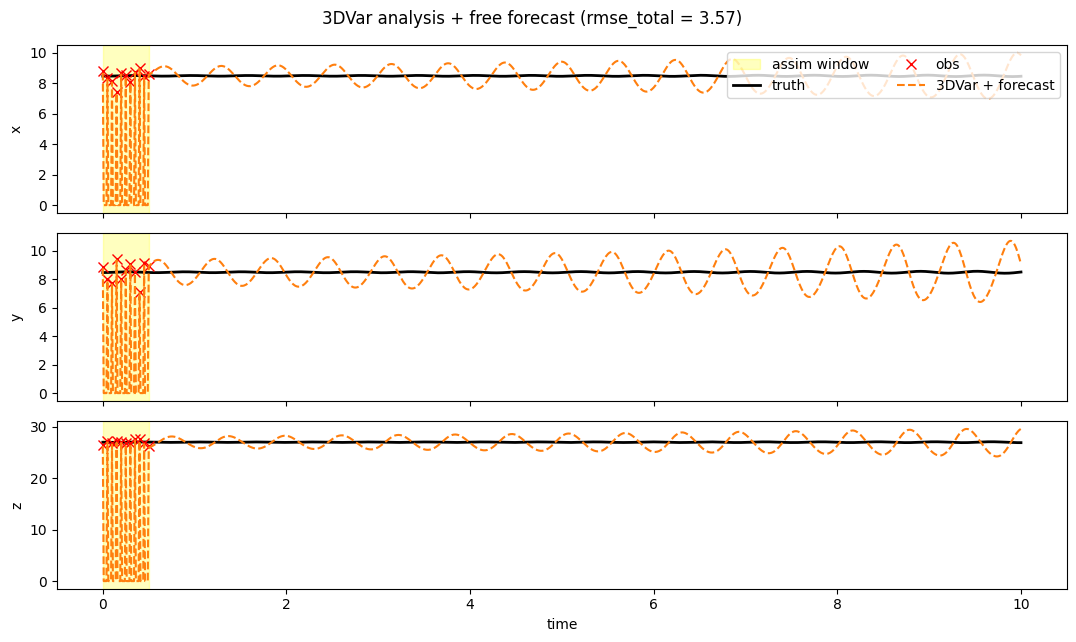

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
t_obs = t_axis[: prob.T_assim_plus_1][prob.mask[:, 0] > 0.5]
for i, ax in enumerate(axs):
    ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25,
               label="assim window")
    ax.plot(t_axis, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_v = prob.obs[prob.mask[:, i] > 0.5, i]
    if len(obs_v) > 0:
        ax.plot(t_obs, obs_v, "rx", ms=7, label="obs")
    ax.plot(t_axis, result.mean[:, i], "C1--", lw=1.5, label="3DVar + forecast")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right", ncol=2)
axs[-1].set_xlabel("time")
fig.suptitle(f"3DVar analysis + free forecast (rmse_total = {result.rmse_total:.2f})")
fig.tight_layout()
plt.show()

## 4. RMSE(t)

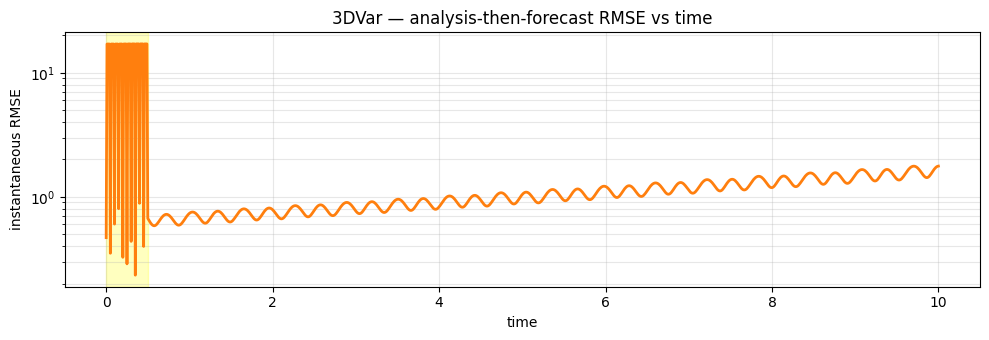

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25)
ax.plot(t_axis, result.rmse_trace, "C1-", lw=2, label="3DVar")
ax.set_xlabel("time")
ax.set_ylabel("instantaneous RMSE")
ax.set_yscale("log")
ax.set_title("3DVar — analysis-then-forecast RMSE vs time")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 5. Discussion

3DVar's iterative solve recovers the same per-time-step analysis as
OI in the linear-Gaussian limit (Decision D14 invariant). RMSE
numbers match OI to within solver tolerance. The free-forecast
story is therefore identical: a noisy launch state from a method
that doesn't propagate information through time gives a forecast
that lags truth and slowly diverges.

The point of 3DVar in the vardax hierarchy isn't speed: it's that
**nonlinear observation operators** become straightforward — swap
`LinearObs` for `AveragingKernel` and the same iterative cost still
minimises. That generality is wasted on this linear-Gaussian L63
problem; see [`03_strong_4dvar`](03_strong_4dvar.ipynb) for the
dynamics constraint that finally lets the forecast horizon extend
past one Lyapunov time.